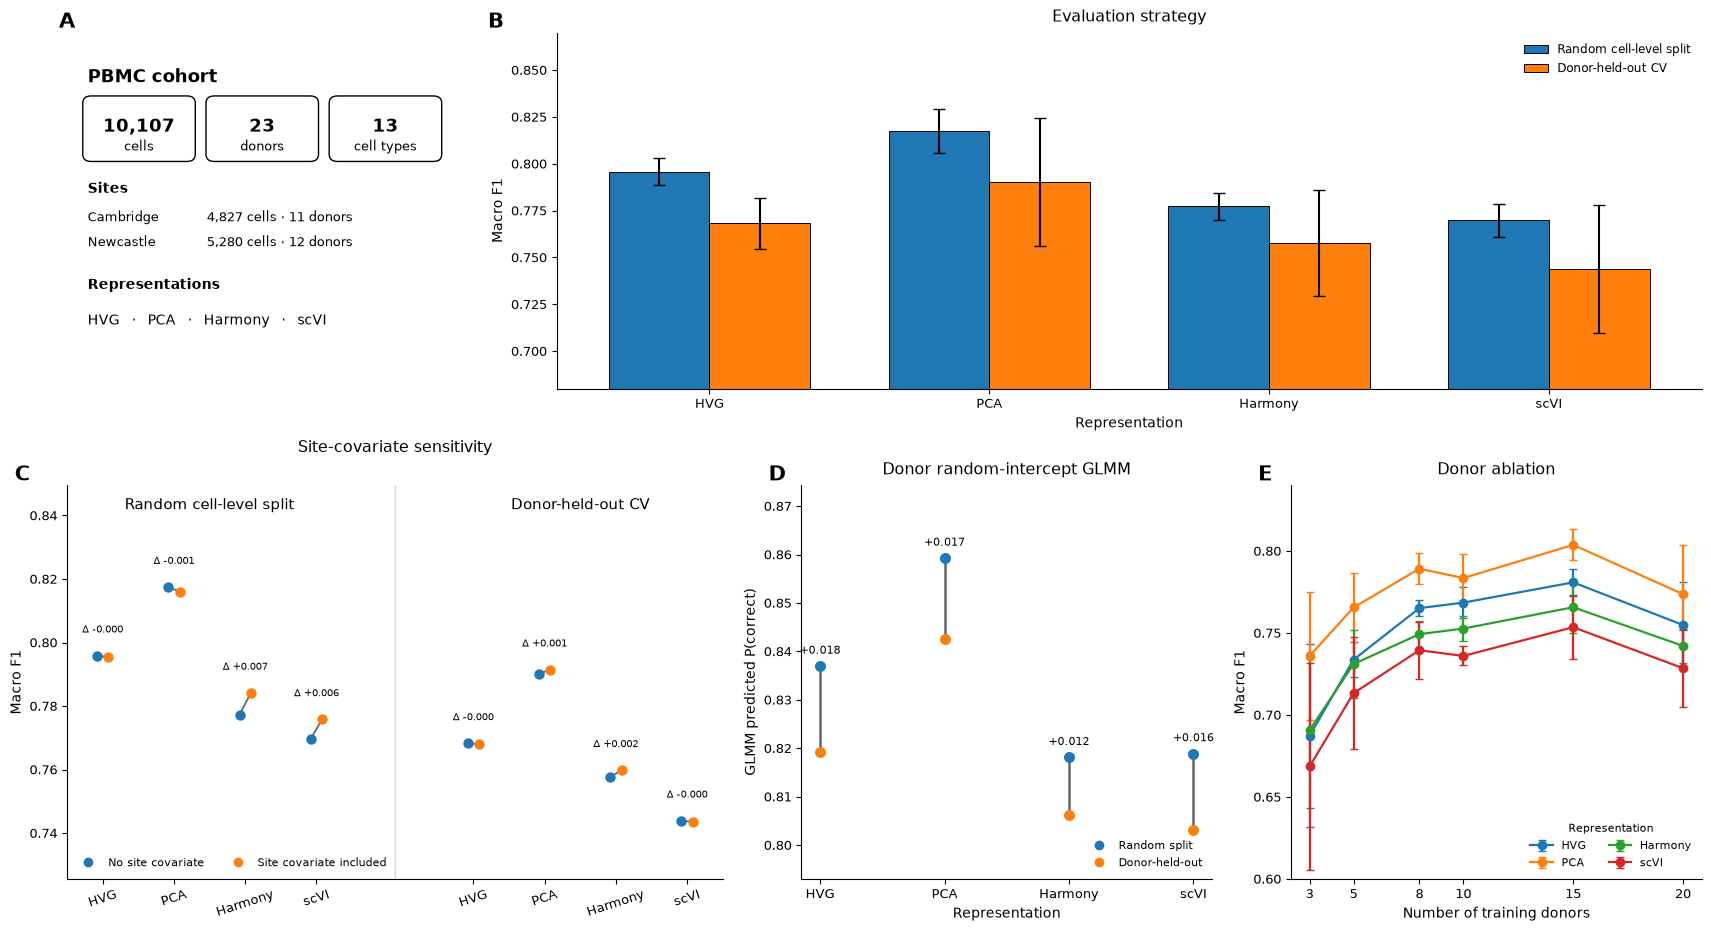

In [1]:
from pathlib import Path
import sys

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch


# ============================================================
# 1. Locate repository
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    for p in [start, *start.parents]:
        if (p / "src" / "scrna_benchmark").is_dir():
            return p

    raise RuntimeError(
        "Run this notebook from somewhere inside the repository."
    )


REPO_ROOT = find_repo_root()

if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(
        0,
        str(REPO_ROOT / "src"),
    )


# ============================================================
# 2. Paths
# ============================================================

ADATA_PATH = (
    REPO_ROOT
    / "data/PBMC_Stephenson/stephenson_benchmark_ready.h5ad"
)

PRIMARY_DIR = (
    REPO_ROOT
    / "results/pbmc_no_batch"
)

SITE_DIR = (
    REPO_ROOT
    / "results/pbmc_with_site_covariate"
)

RANDOM_PATH = (
    PRIMARY_DIR
    / "random_split/random_split_repeated_metrics.csv"
)

DONOR_PATH = (
    PRIMARY_DIR
    / "donor_cv/metrics.csv"
)

SITE_RANDOM_PATH = (
    SITE_DIR
    / "random_split/random_split_repeated_metrics.csv"
)

SITE_DONOR_PATH = (
    SITE_DIR
    / "donor_cv/metrics.csv"
)

GLMM_PATH = (
    PRIMARY_DIR
    / "mixed_models/correctness_glmm_predicted_probabilities.csv"
)

ABLATION_PATH = (
    PRIMARY_DIR
    / "donor_ablation/donor_ablation_summary.csv"
)

FIG_DIR = (
    REPO_ROOT
    / "manuscript_figures"
)


# ============================================================
# 3. Validate inputs
# ============================================================

required = [
    ADATA_PATH,
    RANDOM_PATH,
    DONOR_PATH,
    SITE_RANDOM_PATH,
    SITE_DONOR_PATH,
    GLMM_PATH,
    ABLATION_PATH,
]

missing = [
    p for p in required
    if not p.exists()
]

if missing:
    raise FileNotFoundError(
        "Missing required Figure 2 inputs:\n"
        + "\n".join(str(p) for p in missing)
    )


# ============================================================
# 4. Cohort information
# ============================================================

adata = ad.read_h5ad(
    ADATA_PATH,
    backed="r",
)

n_cells = adata.n_obs

n_donors = (
    adata.obs["patient_id"]
    .astype(str)
    .nunique()
)

n_cell_types = (
    adata.obs["cell_type"]
    .astype(str)
    .nunique()
)

obs_summary = pd.DataFrame({
    "Site": adata.obs["Site"].astype(str),
    "patient_id": adata.obs["patient_id"].astype(str),
})

site_summary = (
    obs_summary
    .groupby(
        "Site",
        observed=True,
    )
    .agg(
        n_cells=("Site", "size"),
        n_donors=("patient_id", "nunique"),
    )
)

if (
    hasattr(adata, "file")
    and adata.file is not None
):
    adata.file.close()


# ============================================================
# 5. Load numerical results
# ============================================================

random_df = pd.read_csv(
    RANDOM_PATH
)

donor_df = pd.read_csv(
    DONOR_PATH
)

site_random_df = pd.read_csv(
    SITE_RANDOM_PATH
)

site_donor_df = pd.read_csv(
    SITE_DONOR_PATH
)

glmm_df = pd.read_csv(
    GLMM_PATH
)

ablation_df = pd.read_csv(
    ABLATION_PATH
)


# ============================================================
# 6. Representation order
# ============================================================

REP_ORDER = [
    "hvg",
    "pca",
    "harmony",
    "scvi",
]

REP_LABELS = {
    "hvg": "HVG",
    "pca": "PCA",
    "harmony": "Harmony",
    "scvi": "scVI",
}


# ============================================================
# 7. Panel B summaries
# ============================================================

random_summary = (
    random_df
    .groupby("representation")["macro_f1"]
    .agg(["mean", "std"])
    .reindex(REP_ORDER)
)

donor_summary = (
    donor_df
    .set_index("representation")
    .reindex(REP_ORDER)
)


# ============================================================
# 8. Panel C summaries
# ============================================================

site_random_summary = (
    site_random_df
    .groupby("representation")["macro_f1"]
    .mean()
    .reindex(REP_ORDER)
)

site_donor_summary = (
    site_donor_df
    .set_index("representation")["macro_f1_mean"]
    .reindex(REP_ORDER)
)

random_delta = (
    site_random_summary
    - random_summary["mean"]
)

donor_delta = (
    site_donor_summary
    - donor_summary["macro_f1_mean"]
)


# ============================================================
# 9. Panel D GLMM summaries
# ============================================================

glmm_plot = glmm_df.copy()

glmm_plot["representation"] = (
    glmm_plot["representation"]
    .astype(str)
)

glmm_plot["scheme"] = (
    glmm_plot["scheme"]
    .astype(str)
)

scheme_rename = {
    "random": "Random split",
    "random_split": "Random split",

    "donor_held_out": "Donor-held-out",
    "donor-held-out": "Donor-held-out",
    "donor_cv": "Donor-held-out",
}

glmm_plot["scheme_clean"] = (
    glmm_plot["scheme"]
    .map(scheme_rename)
    .fillna(glmm_plot["scheme"])
)

glmm_wide = (
    glmm_plot
    .pivot(
        index="representation",
        columns="scheme_clean",
        values="pred_prob_correct",
    )
    .reindex(REP_ORDER)
)


# ============================================================
# 10. Styling
# ============================================================

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11.5,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
})

BLUE = "#1f77b4"
ORANGE = "#ff7f0e"
GRAY = "#666666"


def clean_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def panel_letter(
    ax,
    letter,
    x=-0.08,
    y=1.03,
):
    ax.text(
        x,
        y,
        letter,
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        va="bottom",
        ha="left",
        clip_on=False,
    )


# ============================================================
# 11. Figure layout
#
#    A |                 B
#   --------------------------------
#          C       |   D   |   E
#
# ============================================================

fig = plt.figure(
    figsize=(17, 9.2),
    layout="constrained",
)

outer = fig.add_gridspec(
    2,
    14,
    height_ratios=[
        0.95,
        1.05,
    ],
)


# Top row
axA = fig.add_subplot(
    outer[0, 0:4]
)

axB = fig.add_subplot(
    outer[0, 4:14]
)


# Bottom row
axC = fig.add_subplot(
    outer[1, 0:6]
)

axD = fig.add_subplot(
    outer[1, 6:10]
)

axE = fig.add_subplot(
    outer[1, 10:14]
)


# ============================================================
# A. PBMC cohort overview
# ============================================================

panel_letter(
    axA,
    "A",
    x=-0.02,
    y=1.00,
)

axA.axis("off")

axA.set_xlim(
    0,
    1,
)

axA.set_ylim(
    0,
    1,
)


axA.text(
    0.05,
    0.90,
    "PBMC cohort",
    fontsize=13,
    fontweight="bold",
    va="top",
)


stats = [
    (
        f"{n_cells:,}",
        "cells",
    ),
    (
        f"{n_donors}",
        "donors",
    ),
    (
        f"{n_cell_types}",
        "cell types",
    ),
]


for x0, (big, small) in zip(
    [0.05, 0.35, 0.65],
    stats,
):

    box = FancyBboxPatch(
        (
            x0,
            0.65,
        ),
        0.25,
        0.16,
        boxstyle=(
            "round,"
            "pad=0.012,"
            "rounding_size=0.02"
        ),
        linewidth=1.0,
        facecolor="white",
    )

    axA.add_patch(
        box
    )

    axA.text(
        x0 + 0.125,
        0.735,
        big,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
    )

    axA.text(
        x0 + 0.125,
        0.680,
        small,
        ha="center",
        va="center",
        fontsize=9,
    )


axA.text(
    0.05,
    0.55,
    "Sites",
    fontweight="bold",
)


site_label_map = {
    "Cambridge": "Cambridge",
    "Ncl": "Newcastle",
}


if "Cambridge" in site_summary.index:

    row = site_summary.loc[
        "Cambridge"
    ]

    axA.text(
        0.05,
        0.47,
        "Cambridge",
        fontsize=9.5,
    )

    axA.text(
        0.34,
        0.47,
        (
            f"{int(row['n_cells']):,} cells · "
            f"{int(row['n_donors'])} donors"
        ),
        fontsize=9.5,
    )


if "Ncl" in site_summary.index:

    row = site_summary.loc[
        "Ncl"
    ]

    axA.text(
        0.05,
        0.40,
        "Newcastle",
        fontsize=9.5,
    )

    axA.text(
        0.34,
        0.40,
        (
            f"{int(row['n_cells']):,} cells · "
            f"{int(row['n_donors'])} donors"
        ),
        fontsize=9.5,
    )


axA.text(
    0.05,
    0.28,
    "Representations",
    fontweight="bold",
)

axA.text(
    0.05,
    0.18,
    "HVG   ·   PCA   ·   Harmony   ·   scVI",
    fontsize=10,
)


# ============================================================
# B. Evaluation strategy
# ============================================================

panel_letter(
    axB,
    "B",
    x=-0.06,
    y=1.00,
)


x = np.arange(
    len(REP_ORDER)
)

bar_width = 0.36


axB.bar(
    x - bar_width / 2,
    random_summary[
        "mean"
    ].to_numpy(),
    width=bar_width,
    yerr=random_summary[
        "std"
    ].to_numpy(),
    capsize=4,
    color=BLUE,
    edgecolor="black",
    linewidth=0.7,
    label="Random cell-level split",
)


axB.bar(
    x + bar_width / 2,
    donor_summary[
        "macro_f1_mean"
    ].to_numpy(),
    width=bar_width,
    yerr=donor_summary[
        "macro_f1_std"
    ].to_numpy(),
    capsize=4,
    color=ORANGE,
    edgecolor="black",
    linewidth=0.7,
    label="Donor-held-out CV",
)


axB.set_xticks(
    x,
    [
        REP_LABELS[r]
        for r in REP_ORDER
    ],
)


axB.set_ylabel(
    "Macro F1"
)

axB.set_xlabel(
    "Representation"
)

axB.set_title(
    "Evaluation strategy",
    pad=8,
)

axB.set_ylim(
    0.68,
    0.87,
)

axB.legend(
    frameon=False,
    loc="upper right",
)

clean_axis(
    axB
)


# ============================================================
# C. Site-covariate sensitivity
#
# One shared axis instead of two subplots.
# This is the main spacing fix.
# ============================================================

panel_letter(
    axC,
    "C",
    x=-0.08,
    y=1.00,
)


# Random-split positions
x_random = np.arange(
    len(REP_ORDER)
)

# Leave an intentional gap before donor-CV group
x_donor = (
    np.arange(
        len(REP_ORDER)
    )
    + 5.2
)

dx = 0.08


c_ymin = (
    min(
        random_summary["mean"].min(),
        donor_summary[
            "macro_f1_mean"
        ].min(),
        site_random_summary.min(),
        site_donor_summary.min(),
    )
    - 0.018
)

c_ymax = (
    max(
        random_summary["mean"].max(),
        donor_summary[
            "macro_f1_mean"
        ].max(),
        site_random_summary.max(),
        site_donor_summary.max(),
    )
    + 0.032
)


def add_covariate_group(
    ax,
    positions,
    base_values,
    cov_values,
    deltas,
):

    for xpos, rep in zip(
        positions,
        REP_ORDER,
    ):

        y_base = base_values.loc[
            rep
        ]

        y_cov = cov_values.loc[
            rep
        ]


        # Paired connector
        ax.plot(
            [
                xpos - dx,
                xpos + dx,
            ],
            [
                y_base,
                y_cov,
            ],
            color=GRAY,
            linewidth=1.3,
            zorder=1,
        )


        # Without site covariate
        ax.scatter(
            xpos - dx,
            y_base,
            s=42,
            color=BLUE,
            zorder=3,
        )


        # With site covariate
        ax.scatter(
            xpos + dx,
            y_cov,
            s=42,
            color=ORANGE,
            zorder=3,
        )


        delta = deltas.loc[
            rep
        ]

        ax.text(
            xpos,
            max(
                y_base,
                y_cov,
            ) + 0.0065,
            f"Δ {delta:+.3f}",
            ha="center",
            va="bottom",
            fontsize=7.5,
        )


add_covariate_group(
    axC,
    x_random,
    random_summary[
        "mean"
    ],
    site_random_summary,
    random_delta,
)


add_covariate_group(
    axC,
    x_donor,
    donor_summary[
        "macro_f1_mean"
    ],
    site_donor_summary,
    donor_delta,
)


# Light divider between evaluation schemes
axC.axvline(
    4.1,
    color="0.85",
    linewidth=1.0,
)


all_positions = np.concatenate([
    x_random,
    x_donor,
])


all_labels = (
    [
        REP_LABELS[r]
        for r in REP_ORDER
    ]
    * 2
)


axC.set_xticks(
    all_positions,
    all_labels,
    rotation=18,
)


axC.set_ylim(
    c_ymin,
    c_ymax,
)


axC.set_ylabel(
    "Macro F1"
)


axC.set_title(
    "Site-covariate sensitivity",
    pad=24,
)


# Group headers inside the panel
axC.text(
    np.mean(x_random),
    c_ymax - 0.004,
    "Random cell-level split",
    ha="center",
    va="top",
    fontsize=10.5,
)

axC.text(
    np.mean(x_donor),
    c_ymax - 0.004,
    "Donor-held-out CV",
    ha="center",
    va="top",
    fontsize=10.5,
)


handles_C = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        color=BLUE,
        markersize=6,
        label="No site covariate",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        color=ORANGE,
        markersize=6,
        label="Site covariate included",
    ),
]


axC.legend(
    handles=handles_C,
    frameon=False,
    loc="lower left",
    ncol=2,
    fontsize=8,
)


clean_axis(
    axC
)


# ============================================================
# D. Donor random-intercept GLMM
# ============================================================

panel_letter(
    axD,
    "D",
    x=-0.08,
    y=1.00,
)


xpos = np.arange(
    len(REP_ORDER)
)


for i, rep in enumerate(
    REP_ORDER
):

    donor_val = glmm_wide.loc[
        rep,
        "Donor-held-out",
    ]

    random_val = glmm_wide.loc[
        rep,
        "Random split",
    ]


    # Paired connector
    axD.plot(
        [
            i,
            i,
        ],
        [
            donor_val,
            random_val,
        ],
        color=GRAY,
        linewidth=1.8,
        zorder=1,
    )


    # Random split
    axD.scatter(
        i,
        random_val,
        s=48,
        color=BLUE,
        zorder=3,
    )


    # Donor-held-out
    axD.scatter(
        i,
        donor_val,
        s=48,
        color=ORANGE,
        zorder=3,
    )


    delta = (
        random_val
        - donor_val
    )


    axD.text(
        i,
        max(
            random_val,
            donor_val,
        ) + 0.002,
        f"+{delta:.3f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )


axD.set_xticks(
    xpos,
    [
        REP_LABELS[r]
        for r in REP_ORDER
    ],
)


axD.set_xlabel(
    "Representation"
)


axD.set_ylabel(
    "GLMM predicted P(correct)"
)


axD.set_title(
    "Donor random-intercept GLMM",
    pad=8,
)


glmm_min = (
    glmm_wide
    .min()
    .min()
)

glmm_max = (
    glmm_wide
    .max()
    .max()
)


axD.set_ylim(
    glmm_min - 0.01,
    glmm_max + 0.015,
)


handles_D = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        color=BLUE,
        markersize=6,
        label="Random split",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        color=ORANGE,
        markersize=6,
        label="Donor-held-out",
    ),
]


axD.legend(
    handles=handles_D,
    frameon=False,
    loc="lower right",
    fontsize=8,
)


clean_axis(
    axD
)

# ============================================================
# E. Donor ablation
# ============================================================

panel_letter(
    axE,
    "E",
    x=-0.08,
    y=1.00,
)


for rep in REP_ORDER:

    sub = (
        ablation_df[
            ablation_df[
                "representation"
            ].eq(rep)
        ]
        .sort_values(
            "k_train_donors"
        )
    )


    axE.errorbar(
        sub[
            "k_train_donors"
        ],
        sub[
            "macro_f1_mean"
        ],
        yerr=sub[
            "macro_f1_std"
        ],
        marker="o",
        linewidth=1.6,
        capsize=3,
        label=REP_LABELS[rep],
    )


axE.set_xlabel(
    "Number of training donors"
)

axE.set_ylabel(
    "Macro F1"
)

axE.set_title(
    "Donor ablation",
    pad=8,
)


axE.set_xticks(
    sorted(
        ablation_df[
            "k_train_donors"
        ].unique()
    )
)


axE.set_ylim(
    0.60,
    0.84,
)


axE.legend(
    frameon=False,
    ncol=2,
    fontsize=8,
    title="Representation",
    title_fontsize=8,
    loc="lower right",
)


clean_axis(
    axE
)


# ============================================================
# 12. Display
# ============================================================

# out_png = FIG_DIR / "figure2_pbmc.png"
# out_pdf = FIG_DIR / "figure2_pbmc.pdf"

# fig.savefig(
#     out_png,
#     dpi=300,
#     bbox_inches="tight",
# )

# fig.savefig(
#     out_pdf,
#     bbox_inches="tight",
# )

plt.show()